In [1]:
import os, copy, h5py
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import numpy as np
import pandas as pd
from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, temp_dir
from compas_python_utils.cosmic_integration.ClassCOMPAS import COMPASData
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023, madau_dickinson_sfr
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022, compas_log_skew_normal_distribution_metallicity_distribution
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.cosmology_utils import lookback_time_to_redshift
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict
import matplotlib.pyplot as plt
from population_vis import get_formation_efficiency
import time
import warnings
import scipy
from scipy import stats
from get_ZdepSFRD import skew_metallicity_distribution
import pickle

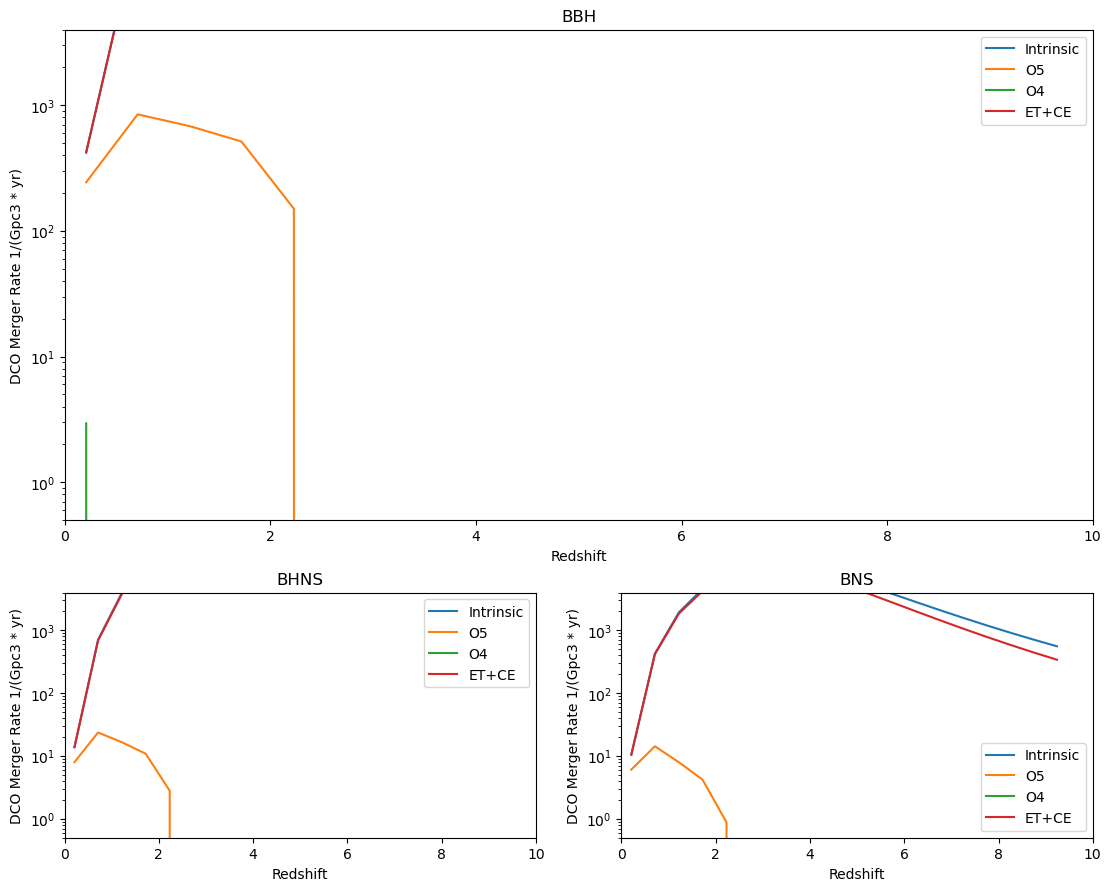

In [ ]:
form_fig = plt.figure(constrained_layout=True, figsize=(11, (8/10)*11))
form_ax = form_fig.subplot_mosaic([
    ['Top', 'Top'],
    ['Left', 'Right']
], height_ratios=[2,1])
# first reproduce the intrinsic line

def plot_with_cut(fname, ax, intrinsic, label, comoving_volume):
    snr_weights = np.load(fname)
    scale = np.sum(snr_weights, axis=1)/(snr_weights.shape[1])
    p_line = np.sum(intrinsic['all_weights'],axis=0)*scale*comoving_volume
    ax.plot(
        intrinsic['redshifts'],
        p_line,
        label=label
    )
    # print(intrinsic['redshifts'])
    ax.set_xlabel('Redshift')
    ax.set_ylabel('DCO Merger Rate 1/(yr)')
    ax.set_xlim(0, 10)
    ax.set_ylim(0.5, 4000)
    ax.legend()
    ax.set_yscale('log')

def plot_subpopulation(pop_type, loc):
    with open(f'./fiducial_{pop_type}.pkl', 'rb') as p:
        intrinsic = pickle.load(p)
        global form_ax
        ax = form_ax[loc]
        comoving_volume = Planck13.comoving_volume(intrinsic['redshifts']).to(u.Gpc**3).value

        ax.plot(intrinsic['redshifts'], np.sum(intrinsic['all_weights'],axis=0)*comoving_volume, label='Intrinsic')
        # now also plot the SNR cuts
        plot_with_cut('BBH_O5_8.npy', ax, intrinsic, 'O5', comoving_volume)
        plot_with_cut('BBH_O4_8.npy', ax, intrinsic, 'O4', comoving_volume)
        plot_with_cut('BBH_ET_CE_10.npy', ax, intrinsic, 'ET+CE', comoving_volume)
        ax.set_title(pop_type)
        p.close()
plot_subpopulation('BBH', 'Top')
plot_subpopulation('BHNS', 'Left')
plot_subpopulation('BNS', 'Right')